### Required Libraries

In [2]:
import pandas as pd
from xgboost import XGBClassifier
from xgboost import plot_importance
from matplotlib import pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score,precision_score,roc_auc_score,accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from sklearn.svm import SVC
import seaborn as sns
import numpy as np
import operator
import glob
import os
from ctgan import CTGAN
from sdmetrics.reports.single_table import QualityReport
from imblearn.over_sampling import SMOTE


In [3]:
#! pip install ctgan
#! pip install sdmetrics

In [4]:
# Our function to load our csv file
def load_dataset(folder):
  files = glob.glob(folder+"/*.csv")
  df_list = []
  df = None
  for file in files:
    df = pd.read_csv(file)
    #df['source_file'] = os.path.basename(file)
    df_list.append(df)

  if len(df_list) == 1:
    return df
  else:
    return pd.concat([df_list],ignore_index=True).sample(frac=1).reset_index(drop=True)


In [5]:
!unzip "/content/archive.zip" -d "/content/datasets"

Archive:  /content/archive.zip
  inflating: /content/datasets/creditcard.csv  


In [6]:
# Our first datasets
credit_df = load_dataset("/content/datasets")

In [7]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# Check if we have null values
credit_df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
def xgb_recall(preds, dtrain):
    labels = dtrain.get_label()
    return 'recall',  recall_score(labels, np.round(preds))

def xgb_precision(preds, dtrain):
    labels = dtrain.get_label()
    return 'precision',  precision_score(labels, np.round(preds))


def xgb_roc_auc(preds, dtrain):
    labels = dtrain.get_label()
    return 'roc_auc',  roc_auc_score(labels, preds)

In [33]:
# Defining our function to train xgb_model
def train_xgboost(xgb_params,ds_train,ds_test):
  result_dict = {}
  xgb_model = xgb.train(
      xgb_params, ds_train, num_boost_round=100,
      verbose_eval=False,
      early_stopping_rounds=30,
      evals=[(ds_train, 'train'), (ds_test, 'test')],
      evals_result=result_dict,
      #feval=xgb_recall, maximize=True
  )

  return xgb_model,result_dict



In [11]:
def plot_xgb_training_curve(results_dict,xgb_model):
  for i in results_dict:
    for err in results_dict[i]:
      plt.plot(results_dict[i][err], label=i+' '+err)

  plt.axvline(xgb_model.best_iteration, c='green', label='best iteration')
  plt.xlabel('iteration')
  # plt.ylabel(err)
  plt.title('xgboost learning curves')
  plt.legend()
  plt.grid()

In [61]:
def xgbplot_feature_importance(xgb_model,max_num_features=10,figsize=(6,6)):
  fig,ax = plt.subplots(1,1,figsize=figsize)
  xgb.plot_importance(xgb_model,max_num_features=max_num_features,height=0.5,ax=ax,color='#B71C1C')

In [69]:
def plot_frequency_distribution(df,column,xlabel,ylabel,title,names = ['Normal','Fraud']):
  plt.figure(figsize=(6,4))
  x1 = df.loc[df.Class == 0, column]
  x2 = df.loc[df.Class == 1, column]
  colors = ['#1B5E20','#B71C1C']
  names = names
  ax = plt.hist([x1,x2], color=colors, label=names,density=True,bins=np.linspace(0,24,25))
  plt.legend()
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.show()

In [73]:
def kde_plot_frequency(df,column,xlabel,ylabel,title,names = ['Normal','Fraud']):
  plt.figure(figsize=(6,4))
  x1 = df.loc[df.Class == 0, column]
  x2 = df.loc[df.Class == 1, column]
  transactions = [x1,x2]
  sns.displot(df,kind="kde",x=column,hue='Class',common_norm=False,linewidth=2,
  palette=['#B71C1C','#1B5E20'],legend=False)
  plt.legend(names,title='Transactions')
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.show()

In [15]:
class BaseGAN(nn.Module):

  def __init__(self,feature_dim,latent_dim=128,hidden_dims=(256, 512, 1024)):

      super().__init__()

      self.feature_dim = feature_dim
      self.latent_dim = latent_dim

      self.generator = nn.Sequential(

          nn.Linear(latent_dim, hidden_dims[0]),
          nn.BatchNorm1d(hidden_dims[0]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[0], hidden_dims[1]),
          nn.BatchNorm1d(hidden_dims[1]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[1], hidden_dims[2]),
          nn.BatchNorm1d(hidden_dims[2]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[2], feature_dim) )

      self.critic = nn.Sequential(

          nn.Linear(feature_dim, hidden_dims[2]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[2], hidden_dims[1]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[1], hidden_dims[0]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[0], 1)

      )


  def generate(self, z):
    return self.generator(z)


  def discriminate(self, x):
    return self.critic(x)

  def sample_noise(self, batch_size, device):
    return torch.randn(batch_size,self.latent_dim, device=device)

  def gradient_penalty(self,real_samples,fake_samples,device):

    batch_size = real_samples.size(0)
    epsilon = torch.rand(
          batch_size,
          1,
          device=device
      )

    epsilon = epsilon.expand_as(real_samples)

    interpolated = (
          epsilon * real_samples +
          (1 - epsilon) * fake_samples
      )

    interpolated.requires_grad_(True)

    mixed_scores = self.discriminate(
          interpolated
      )

    gradients = torch.autograd.grad(
          outputs=mixed_scores,
          inputs=interpolated,
          grad_outputs=torch.ones_like(
              mixed_scores
          ),
          create_graph=True,
          retain_graph=True
      )[0]

    gradients = gradients.view(
          batch_size,
          -1
      )

    gradient_norm = gradients.norm(
          2,
          dim=1
      )

    gp = (
          (gradient_norm - 1) ** 2
      ).mean()

    return gp

In [16]:
def train_critic(model,real_batch,optimizer,lambda_gp,device):

  batch_size = real_batch.size(0)
  z = model.sample_noise(
          batch_size,
          device
      )

  fake_batch = model.generate(z)

  critic_real = model.discriminate(
          real_batch
      ).mean()

  critic_fake = model.discriminate(fake_batch.detach()).mean()

  gp = model.gradient_penalty(real_batch,fake_batch.detach(),device)

  loss = (
          -critic_real +
          critic_fake +
          lambda_gp * gp
      )

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  return loss.item()

In [17]:
def train_generator(model,optimizer,batch_size,device):
  z = model.sample_noise(batch_size,device)
  fake_batch = model.generate(z)
  loss = -model.discriminate(fake_batch).mean()
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  return loss.item()

In [18]:
def gan_full_train_loop(model,c_optimizer,epochs,lambda_gp,critic_iter,device,train_loader):

  for epoch in range(epochs):

    for real_batch in train_loader:

      real_batch = real_batch[0].to(device)

      for _ in range(critic_iter):
        critic_loss = train_critic(model,real_batch,c_optimizer,lambda_gp,device)
        generator_loss = train_generator(model,g_optimizer,real_batch.size(0),device)


    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Critic: {critic_loss:.4f} "
        f"Generator: {generator_loss:.4f}"
    )


In [19]:
def plot_tsne_visualization(y_combined,x_tsne,figsize=(12,10)):

  plt.figure(figsize=figsize)
  normal_idx = y_combined == "Normal"
  fraud_idx = y_combined == "Fraud"
  synthetic_idx = y_combined == "Synthetic Fraud"

  plt.scatter(
    x_tsne[normal_idx,0],
    x_tsne[normal_idx,1],
    alpha=0.1,
    s=10,
    label="Normal"
)

  plt.scatter(
      x_tsne[fraud_idx,0],
      x_tsne[fraud_idx,1],
      alpha=0.9,
      s=40,
      label="Real Fraud"
  )

  plt.scatter(
      x_tsne[synthetic_idx,0],
      x_tsne[synthetic_idx,1],
      alpha=0.9,
      s=40,
      marker="x",
      label="Synthetic Fraud"
  )

  plt.legend()
  plt.title("WGAN-GP Fraud Generation Quality")
  plt.show()


In [20]:
# Check if we have some duplicates in our  dataframe
normal_duplicates = sum(credit_df.loc[credit_df.Class == 0].duplicated())
fraude_duplicates = sum(credit_df.loc[credit_df.Class == 1].duplicated())
total_duplicates = normal_duplicates + fraude_duplicates

print("Normal_duplicates: ",normal_duplicates)
print("Fraud_duplicates: ",fraude_duplicates)
print("total_duplicates: ",total_duplicates)
print("Fraction_duplicates: ",total_duplicates/len(credit_df))

Normal_duplicates:  1062
Fraud_duplicates:  19
total_duplicates:  1081
Fraction_duplicates:  0.00379555277784605


# Remove all duplicates by only keeping one occurence


In [21]:
credit_df.shape

(284807, 31)

In [22]:
credit_df = credit_df.drop_duplicates(keep=False)

In [23]:
# Number of columns
len(credit_df.columns)

31

In [24]:
# Show data distribution by class
credit_df.groupby("Class")["Class"].count()

,Class
Class,
0,282493
1,460


### showing the frequency of each category

In [25]:
from collections import Counter
counts = Counter(credit_df['Class'])

print("Number of 1s:", counts[1])
print("Number of 0s:", counts[0])

Number of 1s: 460
Number of 0s: 282493


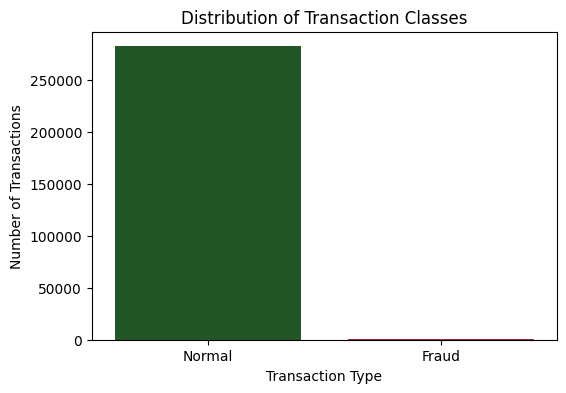

In [27]:
plt.figure(figsize=(6,4))
label_mapping = {0:"Normal",1:"Fraud"}
custom_colors = ['#1B5E20', '#B71C1C']
mapped_class = credit_df['Class'].map(label_mapping)
sns.countplot(x=mapped_class,palette=custom_colors,hue=mapped_class)
plt.title("Distribution of Transaction Classes")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

### XGBoost evaluation on our unbalanced dataset

In [28]:
credit_df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [29]:
x = credit_df.iloc[:,:-1]
y = credit_df["Class"]

x_train_temp,x_test,y_train_temp,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
x_train,x_val,y_train,y_val = train_test_split(x_train_temp,y_train_temp,test_size=0.1,stratify=y_train_temp,random_state=42)

In [30]:
ds_train = xgb.DMatrix(x_train,y_train,feature_names=x_train.columns.tolist())
ds_val = xgb.DMatrix(x_val,y_val,feature_names=x_val.columns.tolist())
ds_test = xgb.DMatrix(x_test,y_test,feature_names=x_test.columns.tolist())


In [34]:
# Training our xgb model on unbalanced dataset
xgb_params = {
    'objective': 'binary:logistic',
    'learning_rate': 0.01,
    'max_depth': 4,
    #'n_estimators': 100,
    'random_state': 42,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

In [35]:
xgb_model,result_dict = train_xgboost(xgb_params,ds_train,ds_val)

In [47]:
# XGBoost model evaluation on unbalanced dataset
y_pred = xgb_model.predict(ds_test, iteration_range=(0, xgb_model.best_iteration + 1))
y_true = y_test.values
print('best iteration: ', xgb_model.best_iteration)
print(xgb_recall(y_pred, ds_test))
print(xgb_precision(y_pred, ds_test))
print(xgb_roc_auc(y_pred, ds_test))
print("accuracy: ",accuracy_score(y_true,np.round(y_pred)))

best iteration:  99
('recall', 0.6521739130434783)
('precision', 0.9523809523809523)
('roc_auc', np.float64(0.9895463713478576))
accuracy:  0.9993815270979485


In [52]:
y_pred = np.round(y_pred).astype(int)

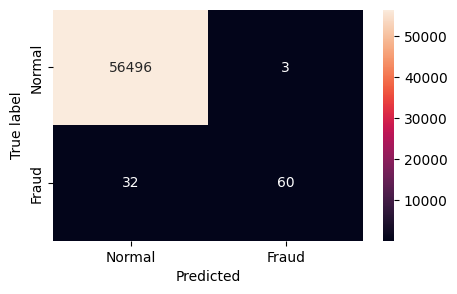

In [56]:
# Plot the confusion matrix
plt.figure(figsize=(5,3))
cm = confusion_matrix(y_true,y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("True label")
plt.show()

In [57]:
#plt.figure(figsize=(5,3))
#cm = confusion_matrix(y_true, np.round(y_pred))
#disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()
#plt.show()

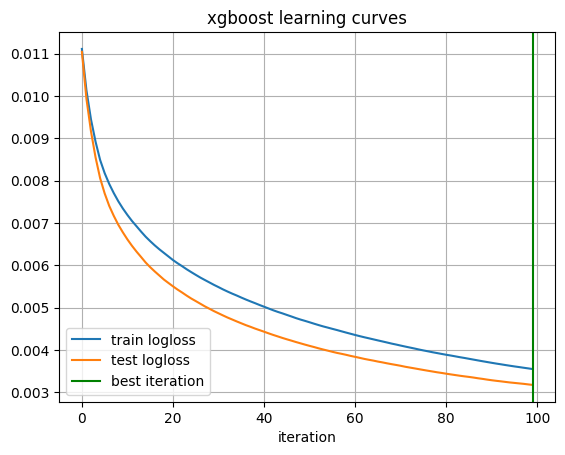

In [58]:
plot_xgb_training_curve(result_dict,xgb_model)

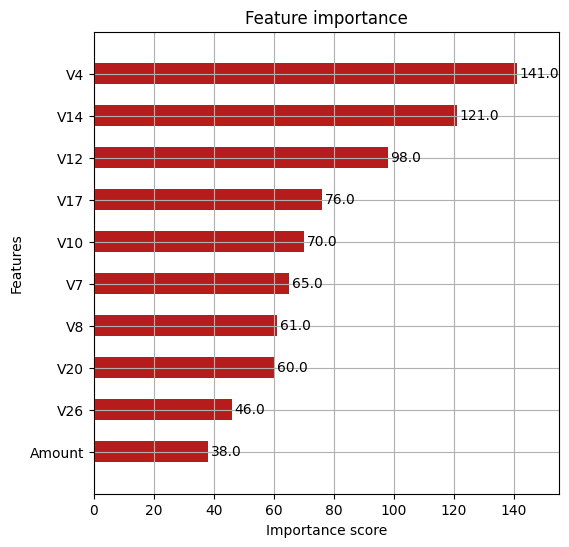

In [62]:
# Showing Feature importance
xgbplot_feature_importance(xgb_model)

In [67]:
score = xgb_model.get_fscore()
sorted_score = sorted(score.items(),key=operator.itemgetter(1), reverse=True)
sorted_cols = [i[0] for i in sorted_score] + ['Class']
print("sorted_cols: ", sorted_cols)

sorted_cols:  ['V4', 'V14', 'V12', 'V17', 'V10', 'V7', 'V8', 'V20', 'V26', 'Amount', 'V11', 'V28', 'V27', 'V3', 'V19', 'V21', 'V16', 'V5', 'V18', 'V2', 'V15', 'V1', 'V13', 'Time', 'V22', 'V6', 'V23', 'V24', 'V25', 'V9', 'Class']


In [66]:
# Apply transformation to time column
credit_df["Time"] = credit_df["Time"].apply(lambda x: convert_time_of_day_to_hour(x))

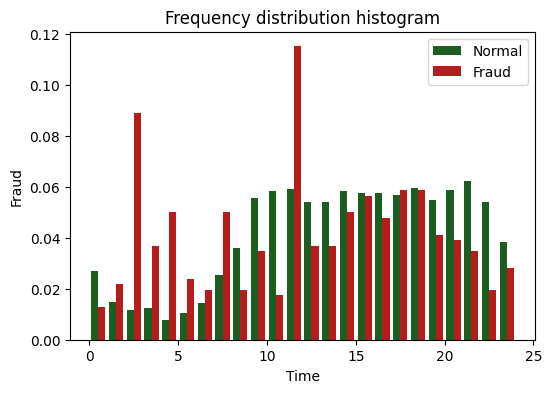

In [70]:
# Frequency distribution histogram
plot_frequency_distribution(credit_df,"Time","Time","Fraud","Frequency distribution histogram")

<Figure size 600x400 with 0 Axes>

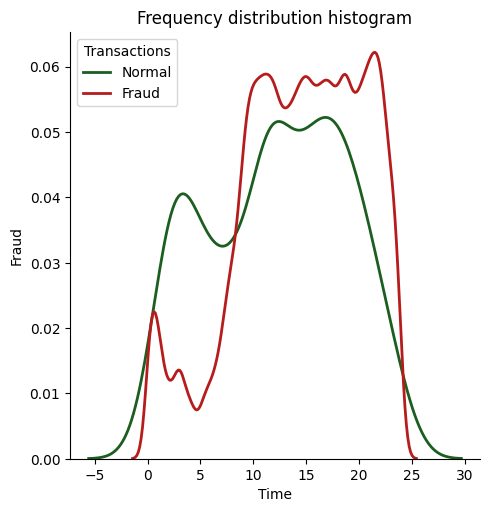

In [74]:
kde_plot_frequency(credit_df,"Time","Time","Fraud","Frequency distribution histogram")

<Figure size 600x400 with 0 Axes>

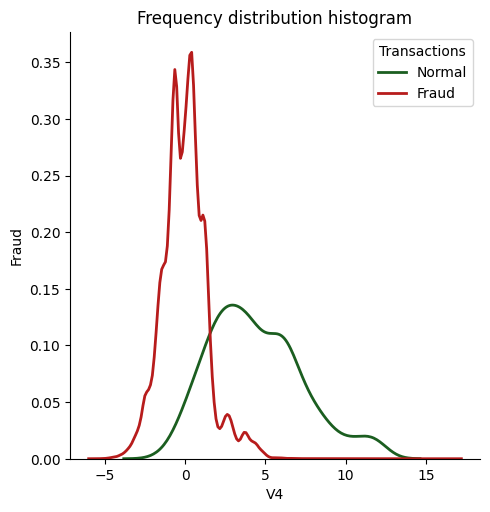

In [75]:
kde_plot_frequency(credit_df,"V4","V4","Fraud","Frequency distribution histogram")

In [76]:
# Show the statistical skewness of our dataset
credit_df.skew()

,0
Time,-0.499223
V1,-3.271779
V2,-4.734674
V3,-2.107315
V4,0.667689
V5,-2.410093
V6,1.832450
V7,3.031678
V8,-8.324049
V9,0.532278


In [77]:
print("minimal_amount: ",credit_df['Amount'].min())
print("maximal_amount: ",credit_df['Amount'].max())
print("percentage_of_amount_equal_to_zeros: ",np.sum(credit_df['Amount'] ==0)/len(credit_df))

minimal_amount:  0.0
maximal_amount:  25691.16
percentage_of_amount_equal_to_zeros:  0.006350878061020735


<Axes: >

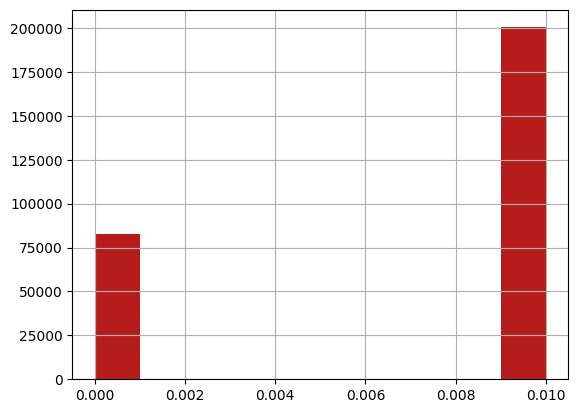

In [79]:
# Frequency distribution of amount
credit_df['Amount'].mod(0.01).hist(color='#B71C1C')

In [87]:
# Apply a logarithmic transformation to amount column
credit_df['Amount'] = np.log1p(credit_df['Amount'])

<Axes: >

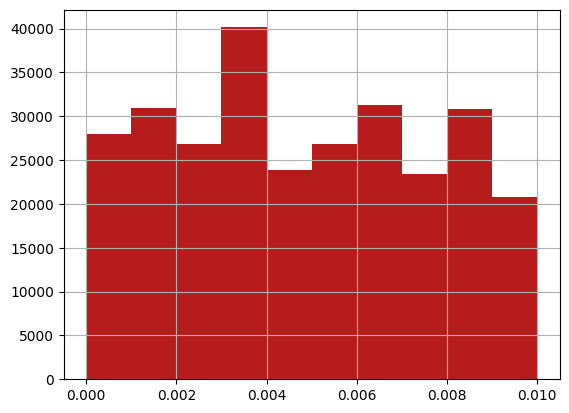

In [88]:
# Frequency distribution of amount after logarithmic transformation of the column amount
credit_df['Amount'].mod(0.01).hist(color='#B71C1C')

### Scaling our dataset

In [89]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760,0
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626,0
2,0.000278,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276,0
3,0.000278,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306,0
4,0.000556,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539,0


In [90]:
# Scaling only Time and Amount column because v1 to v28 are already PCA-transformed and approximately standardized
scaler = StandardScaler()
credit_df["Time"] = scaler.fit_transform(credit_df[["Time"]])
credit_df["Amount"] = scaler.fit_transform(credit_df[["Amount"]])

In [94]:
label_cols = ['Class']
data_cols = list(credit_df.columns[credit_df.columns != 'Class'])

### Initialization of our GAN

In [95]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

gan_model = BaseGAN(feature_dim=len(data_cols),latent_dim=128).to(device)

In [96]:
# Initialize optimizer parametter for the generator and the discriminator
g_optimizer = optim.Adam(
    gan_model.generator.parameters(),
    lr=1e-4,
    betas=(0.0, 0.9)
)

c_optimizer = optim.Adam(
    gan_model.critic.parameters(),
    lr=1e-4,
    betas=(0.0, 0.9)
)

In [97]:
fraud_df = credit_df[credit_df.Class == 1]
normal_df = credit_df[credit_df.Class == 0]
x_tensor = torch.FloatTensor(fraud_df[data_cols].values)
dataset = TensorDataset(x_tensor)

In [98]:
train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    drop_last=True
)

In [99]:
epochs = 500
lambda_gp = 10
critic_iter = 5

In [100]:
for real_batch in train_loader:
  print(real_batch[0].to(device).shape)
  break

torch.Size([64, 30])


In [101]:
# Train our GAN
gan_full_train_loop(gan_model,c_optimizer,epochs,lambda_gp,critic_iter,device,train_loader)

Epoch [1/500] Critic: -18.4873 Generator: -7.7175
Epoch [2/500] Critic: -15.2038 Generator: -14.1578
Epoch [3/500] Critic: -9.8319 Generator: -16.6320
Epoch [4/500] Critic: -7.7861 Generator: -12.6461
Epoch [5/500] Critic: -3.5987 Generator: -8.1822
Epoch [6/500] Critic: -0.2509 Generator: -11.7811
Epoch [7/500] Critic: -2.3089 Generator: 3.0398
Epoch [8/500] Critic: -1.9894 Generator: 7.7399
Epoch [9/500] Critic: -4.2336 Generator: 5.5829
Epoch [10/500] Critic: -2.2522 Generator: 9.8091
Epoch [11/500] Critic: -4.1044 Generator: -10.5126
Epoch [12/500] Critic: -6.2358 Generator: -14.5182
Epoch [13/500] Critic: -4.7624 Generator: 8.0688
Epoch [14/500] Critic: -2.8854 Generator: 8.7116
Epoch [15/500] Critic: -4.0466 Generator: 14.0549
Epoch [16/500] Critic: -3.0751 Generator: 0.6498
Epoch [17/500] Critic: -2.3521 Generator: 5.3768
Epoch [18/500] Critic: -4.3783 Generator: -10.9445
Epoch [19/500] Critic: -3.8389 Generator: -12.4356
Epoch [20/500] Critic: -3.9235 Generator: 2.2636
Epoch [2

In [ ]:
# Train our GAN
gan_full_train_loop(gan_model,c_optimizer,epochs,lambda_gp,critic_iter,device,train_loader)

Epoch [1/500] Critic: -4.0675 Generator: -4.0494
Epoch [2/500] Critic: -3.2321 Generator: -0.8797
Epoch [3/500] Critic: -2.5613 Generator: 6.6586
Epoch [4/500] Critic: -3.3251 Generator: 11.4281
Epoch [5/500] Critic: -4.7940 Generator: -1.8056
Epoch [6/500] Critic: -4.0482 Generator: -9.2112
Epoch [7/500] Critic: -3.8415 Generator: 8.5648
Epoch [8/500] Critic: -3.7656 Generator: 9.4358
Epoch [9/500] Critic: -5.6315 Generator: 4.1819
Epoch [10/500] Critic: -4.4529 Generator: -9.0854
Epoch [11/500] Critic: -3.8772 Generator: 6.0273
Epoch [12/500] Critic: -6.7661 Generator: -11.1607
Epoch [13/500] Critic: -7.7033 Generator: -12.7141
Epoch [14/500] Critic: -5.2402 Generator: -0.5471
Epoch [15/500] Critic: -4.3000 Generator: -8.2674
Epoch [16/500] Critic: -4.3710 Generator: -6.4428
Epoch [17/500] Critic: -3.7839 Generator: 5.8799
Epoch [18/500] Critic: -3.4565 Generator: 11.9187
Epoch [19/500] Critic: -3.6071 Generator: 1.1105
Epoch [20/500] Critic: -4.6889 Generator: -5.5705
Epoch [21/500]

In [102]:
gan_model.eval()

with torch.no_grad():
  z = gan_model.sample_noise(2000,device)
  synthetic_fraud = gan_model.generate(z)
  synthetic_fraud = (synthetic_fraud.cpu().numpy())


In [103]:
synthetic_fraud_df = pd.DataFrame(synthetic_fraud,columns=data_cols)

In [104]:
normal_df["Source"] = "Normal"
normal_df["Class"] = 0
fraud_df["Source"] = "Fraud"
fraud_df["Class"] = 1
synthetic_fraud_df["Source"] = "Synthetic Fraud"
synthetic_fraud_df["Class"] = 2

In [105]:
combined_df = pd.concat([normal_df.sample(2000, random_state=42),fraud_df,synthetic_fraud_df], ignore_index=True)

In [106]:
synthetic_fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Source,Class
0,-2.094890,0.312776,3.362623,-5.989745,5.965631,-1.835874,-1.554564,-2.678029,1.754693,-0.978494,...,-0.717104,1.361396,0.020363,-2.793155,0.402855,0.459875,-0.136734,-0.779654,Synthetic Fraud,2
1,-2.140412,-36.257038,21.214443,-38.579697,9.570323,-26.443338,-5.915294,-25.629940,23.867214,-5.211906,...,-1.960323,-1.554417,-0.169411,3.097623,-0.139088,1.816569,0.235126,1.370593,Synthetic Fraud,2
2,0.878074,-3.340343,3.458362,-5.683640,3.887443,-0.825531,-1.721465,-2.455958,-0.148380,-0.868285,...,0.332388,0.309370,-0.203607,-0.045091,-0.121685,-1.737086,0.577674,0.424072,Synthetic Fraud,2
3,-0.312050,-11.613626,6.084069,-13.856159,7.595390,-10.909365,-2.607530,-12.123425,8.407341,-7.318290,...,-0.544367,-0.038070,0.812730,0.359352,-0.389967,-0.971748,-1.255193,0.624272,Synthetic Fraud,2
4,0.468964,-2.931611,1.742152,-2.666616,2.611948,-1.380971,0.231823,-3.744501,-2.903174,-2.187303,...,0.316878,0.467869,-0.519380,-0.081603,0.183331,-0.065053,0.167681,-0.570806,Synthetic Fraud,2


In [107]:
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Source
541,-2.467790,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,-1.902852,1,Fraud
623,-2.464653,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1.881368,1,Fraud
4920,-2.275040,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,1.405770,1,Fraud
6108,-2.155094,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,0.567131,1,Fraud
6329,-2.129764,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,-1.484699,1,Fraud


In [108]:
x_combined = combined_df[data_cols]
y_combined = combined_df["Source"]

In [109]:
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

In [110]:
X_tsne = tsne.fit_transform(x_combined)

### Display Data distribution

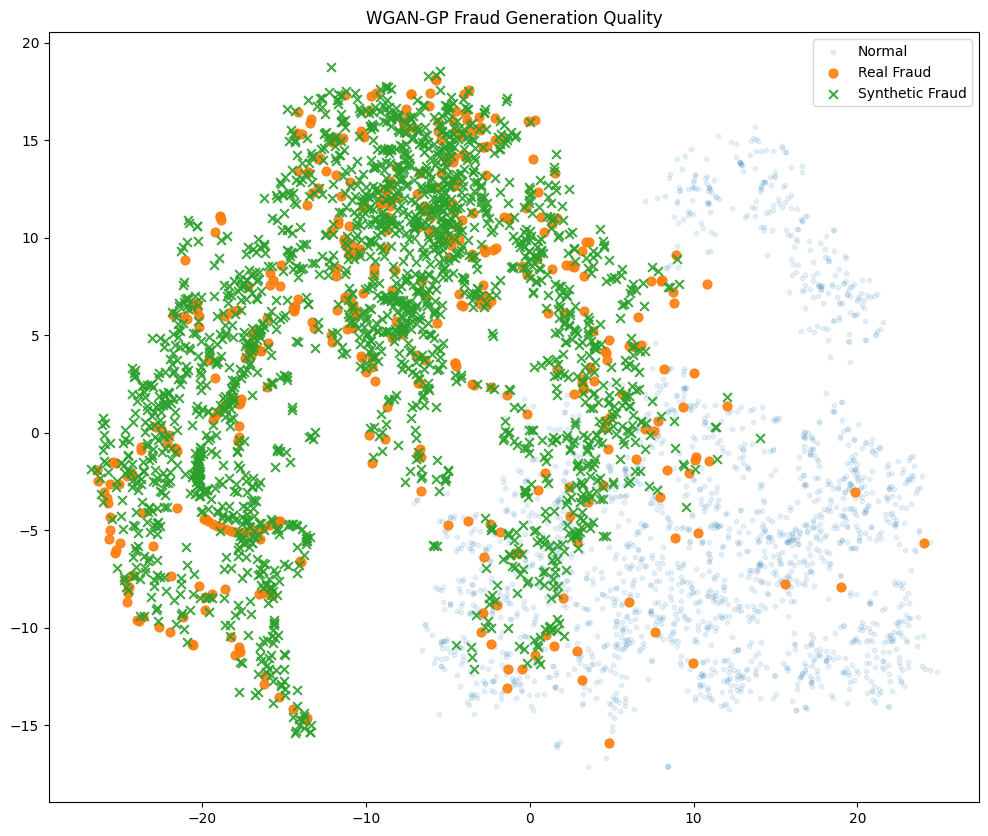

In [111]:
plt.figure(figsize=(12,10))

normal_idx = y_combined == "Normal"
fraud_idx = y_combined == "Fraud"
synthetic_idx = y_combined == "Synthetic Fraud"

plt.scatter(
    X_tsne[normal_idx,0],
    X_tsne[normal_idx,1],
    alpha=0.1,
    s=10,
    label="Normal"
)

plt.scatter(
    X_tsne[fraud_idx,0],
    X_tsne[fraud_idx,1],
    alpha=0.9,
    s=40,
    label="Real Fraud"
)

plt.scatter(
    X_tsne[synthetic_idx,0],
    X_tsne[synthetic_idx,1],
    alpha=0.9,
    s=40,
    marker="x",
    label="Synthetic Fraud"
)

plt.legend()
plt.title("WGAN-GP Fraud Generation Quality")
plt.show()

In [112]:
label_cols = ['Class']
data_cols = list(credit_df.columns[credit_df.columns != 'Class'])

In [113]:
fraud_df = credit_df[credit_df.Class == 1]
normal_df = credit_df[credit_df.Class == 0]

### SMOTE (moderate oversampling)

- Step 1: Moderate SMOTE
- Step 2: Train CTGAN
- Step 3: Generate More Fraud Samples

In [114]:
# Use Smote for moderate oversampling by increasing fraud samples -> 2000

smote = SMOTE(
    sampling_strategy = 2000/len(credit_df[credit_df["Class"] ==0]),
    random_state=42
)

In [115]:
x_smote,y_smote = smote.fit_resample(credit_df[data_cols],credit_df["Class"])

In [116]:
fraud_smote = pd.DataFrame(x_smote[y_smote == 1],columns=credit_df.columns)

In [117]:
fraud_smote["Class"] = 1

In [118]:
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,-2.467790,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,-1.902852,1
623,-2.464653,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1.881368,1
4920,-2.275040,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,1.405770,1
6108,-2.155094,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,0.567131,1
6329,-2.129764,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,-1.484699,1


In [119]:
fraud_df.shape

(460, 31)

In [120]:
fraud_smote.iloc[460:].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
282953,-0.119338,1.258734,0.494097,-0.330627,1.121797,0.380359,-0.246934,0.080130,-0.030541,0.069115,...,-0.068839,-0.122712,-0.172436,-0.781858,0.678994,-0.256681,0.042200,0.034584,-1.469925,1
282954,0.862339,0.607054,2.599937,-4.656329,5.754579,-0.708988,-1.549938,-2.955248,0.608126,-3.016694,...,0.392618,-0.823992,0.098054,-0.378810,0.204353,-0.123334,0.826302,0.405722,-0.993294,1
282955,0.874483,1.130034,1.127167,-1.418236,2.012285,0.638135,-1.090895,0.208724,0.059110,0.030063,...,-0.359616,-0.863366,-0.150902,-0.129290,0.650549,-0.349274,0.075074,0.113442,-1.484699,1
282956,0.803018,1.432920,-0.689993,-0.490437,-0.628876,-0.608484,-0.343584,-0.627975,0.019599,-0.639587,...,0.048607,-0.027497,-0.103859,-0.192070,0.330556,-0.248805,0.003934,0.023068,0.646734,1
282957,-1.164167,0.306943,0.976203,-1.556635,1.919378,-1.887838,-1.171260,-2.799180,0.637571,-0.700987,...,0.594645,0.345354,-0.059397,0.255565,0.328273,0.605157,0.566846,0.306204,0.040545,1


In [121]:
report = QualityReport()
metadata = {
    'columns': {col: {'sdtype': 'numerical'} for col in data_cols}
}

In [122]:
report.generate(
    real_data=fraud_df[data_cols],
    synthetic_data=fraud_smote.iloc[460:][data_cols],
    metadata=metadata
)


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 30/30 [00:00<00:00, 442.36it/s]|
Column Shapes Score: 95.34%

(2/2) Evaluating Column Pair Trends: |██████████| 435/435 [00:02<00:00, 147.51it/s]|
Column Pair Trends Score: 99.23%

Overall Score (Average): 97.28%



In [123]:
details = report.get_details("Column Shapes")
print(details.sort_values("Score"))

    Column        Metric     Score
0     Time  KSComplement  0.926172
29  Amount  KSComplement  0.926510
13     V13  KSComplement  0.937211
24     V24  KSComplement  0.939695
25     V25  KSComplement  0.942490
26     V26  KSComplement  0.943027
19     V19  KSComplement  0.945822
23     V23  KSComplement  0.948419
20     V20  KSComplement  0.949915
22     V22  KSComplement  0.951158
6       V6  KSComplement  0.952089
5       V5  KSComplement  0.952343
28     V28  KSComplement  0.952908
15     V15  KSComplement  0.953303
21     V21  KSComplement  0.953360
4       V4  KSComplement  0.955816
11     V11  KSComplement  0.956465
12     V12  KSComplement  0.957849
27     V27  KSComplement  0.958667
7       V7  KSComplement  0.958893
16     V16  KSComplement  0.960644
1       V1  KSComplement  0.960785
10     V10  KSComplement  0.961547
9       V9  KSComplement  0.961688
14     V14  KSComplement  0.964568
18     V18  KSComplement  0.965443
3       V3  KSComplement  0.965500
2       V2  KSComple

In [124]:
# Testing CTGAN (Conditional Tabular Generative Adversarial Network) for tabular data

ctgan_model = CTGAN(
    embedding_dim=128,
    generator_dim=(256, 256),
    discriminator_dim=(256, 256),
    batch_size=60,
    epochs=3000,
    verbose=True)



In [125]:
ctgan_model.fit(fraud_smote[data_cols])

Gen. (+00.30) | Discrim. (+00.79): 100%|██████████| 3000/3000 [2:00:33<00:00,  2.41s/it]


In [126]:
n_fraud = len(fraud_smote[fraud_smote["Class"] == 1])
n_normal = len(credit_df[credit_df["Class"] == 0])

needed = n_normal - n_fraud

print("Synthetic samples needed:", needed)

Synthetic samples needed: 280493


In [127]:
synthetic_fraud_df = ctgan_model.sample(needed)

In [128]:
synthetic_fraud_df.shape

(280493, 30)

In [129]:
synthetic_fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.118189,-7.519620,6.103077,-15.590154,6.997522,-2.001433,-2.183118,-13.880165,2.208285,-4.485585,...,-0.435876,2.120639,0.360475,0.936971,-0.086966,-1.483595,0.238211,-0.187201,0.133448,-1.092053
1,-0.185289,3.092910,3.229936,-4.649124,6.308316,2.897004,-1.789523,-0.466601,-1.054647,-0.282062,...,-0.128420,0.396401,-0.457715,-0.362645,-0.018631,1.357977,-0.193443,-0.051044,-0.080629,-1.390475
2,1.017211,2.065122,0.562394,-4.394764,0.814452,0.712541,-1.152978,2.008799,-0.506759,0.204648,...,0.137072,-0.569712,-0.236585,-0.564864,-0.697354,-0.151128,-0.259351,0.056187,-0.004143,-1.361965
3,0.485156,2.096821,1.055890,1.075788,1.393374,-0.955494,-0.265617,0.953538,-1.572701,-0.669490,...,0.844377,-0.058609,-0.438892,-0.315914,0.323325,-0.408651,0.453334,0.386637,0.023982,1.413430
4,1.469946,1.691732,-1.613860,1.174319,-0.232460,1.669134,0.338677,1.884850,-1.033324,0.098697,...,0.078318,0.430247,-0.258819,-0.329485,0.197963,-0.209279,-0.353629,-0.063898,-0.052962,0.143493


In [130]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.487084,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.122388,0
1,-2.487084,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.115211,0
2,-2.487036,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.680118,0
3,-2.487036,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.007493,0
4,-2.486989,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.668597,0


### Estimate the quality of the the data that has been generated

In [131]:
report = QualityReport()

In [132]:
metadata = {
    'columns': {col: {'sdtype': 'numerical'} for col in data_cols}
}

report.generate(
    real_data=fraud_df[data_cols],
    synthetic_data=synthetic_fraud_df,
    metadata=metadata
)



Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 30/30 [00:01<00:00, 27.39it/s]|
Column Shapes Score: 91.0%

(2/2) Evaluating Column Pair Trends: |██████████| 435/435 [00:26<00:00, 16.34it/s]|
Column Pair Trends Score: 94.79%

Overall Score (Average): 92.9%



In [133]:
details = report.get_details("Column Shapes")
print(details.sort_values("Score"))

    Column        Metric     Score
29  Amount  KSComplement  0.777548
23     V23  KSComplement  0.843046
1       V1  KSComplement  0.848297
7       V7  KSComplement  0.874752
16     V16  KSComplement  0.882151
22     V22  KSComplement  0.886404
10     V10  KSComplement  0.893713
27     V27  KSComplement  0.896711
25     V25  KSComplement  0.898718
21     V21  KSComplement  0.899045
11     V11  KSComplement  0.903943
20     V20  KSComplement  0.907783
0     Time  KSComplement  0.913941
3       V3  KSComplement  0.913945
5       V5  KSComplement  0.919150
6       V6  KSComplement  0.919990
28     V28  KSComplement  0.920909
19     V19  KSComplement  0.922376
15     V15  KSComplement  0.923401
24     V24  KSComplement  0.926026
2       V2  KSComplement  0.927183
8       V8  KSComplement  0.933888
14     V14  KSComplement  0.936770
4       V4  KSComplement  0.936796
26     V26  KSComplement  0.940383
9       V9  KSComplement  0.944933
13     V13  KSComplement  0.947383
18     V18  KSComple

### Display Data distribution

In [134]:
normal_df["Source"] = "Normal"
normal_df["Class"] = 0
fraud_df["Source"] = "Fraud"
fraud_df["Class"] = 1
synthetic_fraud_df["Source"] = "Synthetic Fraud"
synthetic_fraud_df["Class"] = 1

In [135]:
combined_df = pd.concat([normal_df.sample(2000, random_state=42),fraud_df,synthetic_fraud_df.sample(2000,random_state=42)], ignore_index=True)

In [136]:
x_combined = combined_df[data_cols]
y_combined = combined_df["Source"]

In [137]:
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

In [138]:
x_tsne = tsne.fit_transform(x_combined)

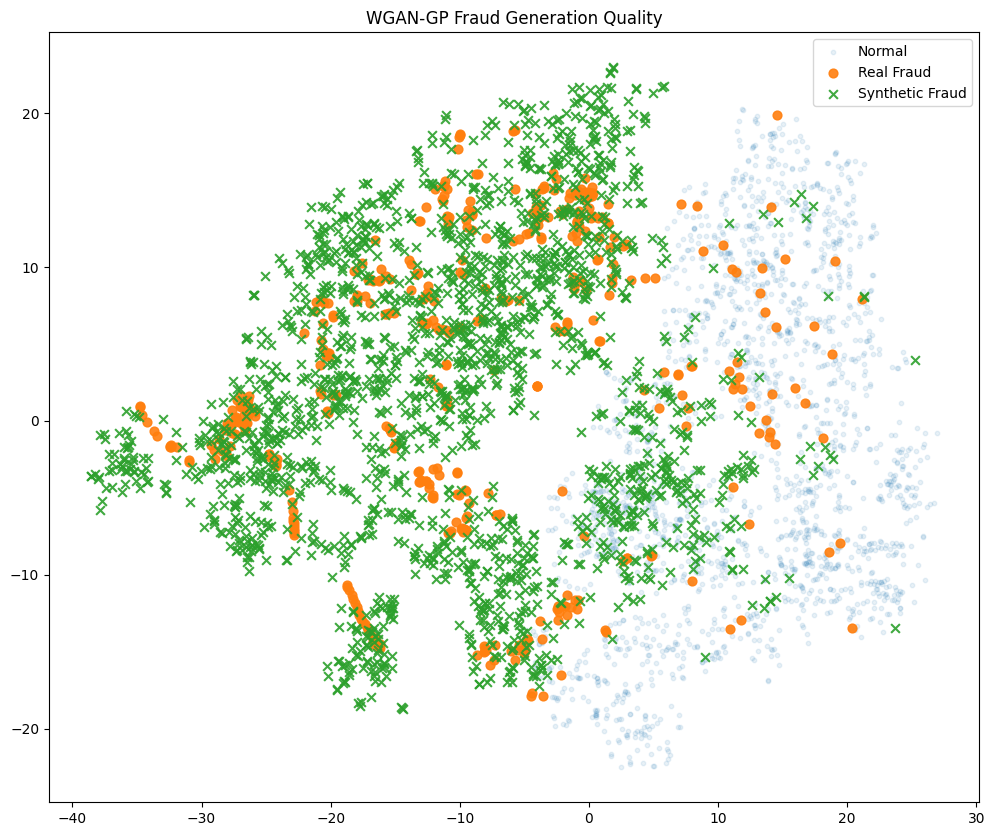

In [139]:
plot_tsne_visualization(y_combined,x_tsne,figsize=(12,10))

#  Merge data to create an augmented dataset

- Original fraud
- Normal transactions
- Synthetic fraud

In [140]:
normal_df = normal_df.drop(columns=["Source"])
fraud_df = fraud_df.drop(columns=["Source"])
synthetic_fraud_df = synthetic_fraud_df.drop(columns=["Source"])

In [141]:
augmented_credit_df = pd.concat([normal_df,fraud_df,synthetic_fraud_df],ignore_index=True)

In [142]:
augmented_credit_df.shape

(563446, 31)

In [143]:
augmented_credit_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.487084,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.122388,0
1,-2.487084,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.115211,0
2,-2.487036,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.680118,0
3,-2.487036,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.007493,0
4,-2.486989,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.668597,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563441,0.433540,-2.141331,2.055187,-6.203782,6.617909,-1.477478,-2.633529,-0.197686,0.270347,-3.357691,...,0.729181,-0.156825,-0.607420,-0.226133,0.963588,-0.079906,-0.132359,0.096324,-1.309996,1
563442,1.631004,1.333326,0.510667,-2.116056,1.250737,-2.878360,-1.574977,2.669504,0.893194,-1.266485,...,-0.222377,0.637823,-0.562486,-0.425331,0.270767,-0.135180,0.501048,0.419106,-1.478435,1
563443,-1.083776,-9.880384,18.198128,-29.993513,6.160618,-22.912090,-3.939841,-22.853302,18.328006,-4.856817,...,-1.744184,-2.019137,-3.200140,-0.136444,1.287551,-0.317305,0.036352,0.070353,0.772842,1
563444,-1.772077,-6.378540,4.029397,-8.016798,7.946830,-3.594739,-3.234355,-0.382601,0.657071,-1.044976,...,1.066623,0.206499,0.033277,-0.307835,0.688038,0.404055,0.463016,0.103150,0.002331,1


In [144]:
augmented_credit_df.groupby("Class")["Class"].count()

,Class
Class,
0,282493
1,280953


In [145]:
normal_duplicates = sum(augmented_credit_df.loc[augmented_credit_df.Class == 0].duplicated())
fraude_duplicates = sum(augmented_credit_df.loc[augmented_credit_df.Class == 1].duplicated())
total_duplicates = normal_duplicates + fraude_duplicates

print("Normal_duplicates: ",normal_duplicates)
print("Fraud_duplicates: ",fraude_duplicates)
print("total_duplicates: ",total_duplicates)
print("Fraction_duplicates: ",total_duplicates/len(augmented_credit_df))

Normal_duplicates:  0
Fraud_duplicates:  0
total_duplicates:  0
Fraction_duplicates:  0.0


In [146]:
augmented_credit_df.to_csv("/content/augmented_creditcard.csv",index=False)

In [147]:
augmented_credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.487084,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.122388,0
1,-2.487084,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.115211,0
2,-2.487036,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.680118,0
3,-2.487036,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.007493,0
4,-2.486989,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.668597,0


In [148]:
temp_df = pd.read_csv("augmented_creditcard.csv")

In [149]:
temp_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.487084,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.122388,0
1,-2.487084,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.115211,0
2,-2.487036,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.680118,0
3,-2.487036,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.007493,0
4,-2.486989,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.668597,0


In [ ]:
x = credit_df.iloc[:,:-1]
y = credit_df["Class"]

x_train_temp,x_test,y_train_temp,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
x_train,x_val,y_train,y_val = train_test_split(x_train_temp,y_train_temp,test_size=0.1,stratify=y_train_temp,random_state=42)